## **Set Up**

In [79]:
import pandas as pd
import matplotlib.pyplot as plt
import math
from statsbombpy import sb
from mplsoccer import VerticalPitch, Pitch
import warnings
import ast

warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)

## **World Cup Data**

In [2]:
# 2018 World Cup Data - Called Via the Statsbomb API
matches_df = sb.matches(competition_id=43, season_id=3)
MatchIds = matches_df.match_id.tolist()
len(MatchIds)

64

# **Get Player Summary for each game**

In [5]:
# The following Method is used to get each player's statline for each game. Refer to Variable Names for stat
def playerStats(df, i):
    df[['x', 'y']] = df['location'].apply(
    lambda loc: pd.Series(loc[:2]) if isinstance(loc, list) else pd.Series([None, None]))

    
    playerName = df.player.tolist()[0]
    matchNum = i
    positions = df.position.unique().tolist()

    shots = df[df.type == "Shot"].shape[0]
    shotOnTarget = (df[(df.type == 'Shot') & ((df.shot_outcome == 'Saved') | (df.shot_outcome == 'Goal'))].shape[0])
    goals = (df[(df.type == 'Shot') & (df.shot_outcome == 'Goal')].shape[0])
    passCompletion = round(sum(df[(df['type'] == 'Pass')].pass_outcome.isna()) / (df[(df['type'] == 'Pass')]).shape[0],2) * 100
    if 'pass_shot_assist' in df.columns:
        keyPasses = (df[df.pass_shot_assist == True].shape[0])
    else:
        keyPasses = 0
    if 'pass_goal_assist' in df.columns:
        assists = (df[df.pass_goal_assist == True].shape[0])
    else:
        assists = 0
    successfulDribbles = (df[df.dribble_outcome == 'Complete'].shape[0])
    tackles = (df[(df.duel_type == 'Tackle') & ((df.duel_outcome != "Lost In Play") & (df.duel_outcome != "Lost Out"))].shape[0])
    interceptions = (df[(df.type == 'Interceptions') & ((df.interception_outcome != "Lost In Play") & (df.interception_outcome != "Lost Out"))].shape[0])
    if "foul_won_penalty" in df.columns:
        penaltyWon = (df[df.foul_won_penalty == True].shape[0])
    else:
        penaltyWon = 0

    
    ownGoal = (df[(df.type == 'Own Goal Against')].shape[0])
    foulCommited = (df[(df.type == 'Foul Committed')].shape[0])
    if "foul_committed_penalty" in df.columns:
        penaltyConceded = (df[df.foul_committed_penalty == True].shape[0])
    else:
        penaltyConceded = 0
    poorShots = (df[(df.type == 'Shot') & ((df.shot_outcome == 'Off T') | (df.shot_outcome == 'Wayward'))].shape[0])
    dispossessed = (df[(df.type == 'Dispossessed')].shape[0])
    dispossessedOwnHalf = (df[(df.type == 'Dispossessed') & (df.x < 60)].shape[0])
    miscontrol = (df[(df.type == 'Miscontrol')].shape[0])
    miscontrolOwnHalf = (df[(df.type == 'Miscontrol') & (df.x < 60)].shape[0])
    errors = (df[(df.type == 'Error')].shape[0])
    if "foul_committed_card" in df.columns:
        yellowCard = (df[df.foul_committed_card == "Yellow Card"].shape[0])
        redCard = (df[(df.foul_committed_card == "Red Card") | (df.foul_committed_card == "Second Yellow")].shape[0])
    else:
        yellowCard = 0
        redCard = 0
    blocks = (df[(df.type == 'Block')].shape[0])
    clearances = (df[(df.type == 'Clearance')].shape[0])
    if "clearance_body_part" in df.columns:
        headedClearance = (df[(df.clearance_body_part == 'Head')].shape[0])
    else:
        headedClearance = 0
    recoveries = (df[(df.type == 'Ball Recovery') & (df.ball_recovery_recovery_failure != True)].shape[0])
    dribbledPast = (df[(df.type == 'Dribbled Past')].shape[0])
    

    player_df = pd.DataFrame({"player": [playerName], "matchNum": [matchNum], "positions": [positions],
    "shots": [shots], "shotsOnTarget": [shotOnTarget], "goals": [goals], "passCompletion": [passCompletion], "keyPasses": [keyPasses], 
    "assists": [assists], "successfulDribbles": [successfulDribbles], "tackles": [tackles], "interceptions": [interceptions],
    "penaltiesWon": [penaltyWon], "ownGoal": [ownGoal], "foulCommitted": [foulCommited], "penaltyConceded": [penaltyConceded], "poorShots": [poorShots],
    "dispossessed": [dispossessed], "dispossessedOwnHalf": [dispossessedOwnHalf], "miscontrol": [miscontrol], "miscontrolOwnHalf": [miscontrolOwnHalf], 
    "errors": [errors], "yellowCard": [yellowCard], "redCard": [redCard], "blocks": [blocks], "clearances": [clearances], "headedClearance": [headedClearance],
    "recoveries": [recoveries], "dribbledPast": [dribbledPast]
    })

    return player_df

In [6]:
# Current Version only covers Position Player
AllGames_Position = []

# For Each Match, Each player will have their statline pulled. Uses Match ID's to get Event data for match and then
# players who played more than 40 Minutes
for i in MatchIds:
    CurrentEvents = sb.events(match_id = i)
    print(i)
    CurrentPlayers = pd.Series(CurrentEvents.player.unique()).dropna().tolist()

    for k in CurrentPlayers:
        PlayerEvents = CurrentEvents[CurrentEvents.player == k]

        if max(PlayerEvents.minute) - min(PlayerEvents.minute) > 40:
            if "Goalkeeper" not in PlayerEvents.position.unique():
                CurrentStats = playerStats(PlayerEvents, i)
                AllGames_Position.append(CurrentStats)

# Event data is concatenated into single Data Frame
AllGames_Df = pd.concat(AllGames_Position, axis=0, ignore_index=True)
        

8650
7584
7554
7539
7550
7538
7534
7543
7544
7546
7545
7585
7569
7572
7561
7540
7531
7570
7586
7557
7542
8656
7548
7578
7553
7536
7555
7576
7565
7551
7537
7580
7581
7549
7529
7562
7571
7568
7530
7558
7583
7547
7535
8649
8658
7582
7552
7532
7560
7533
7564
7579
7577
7525
7566
8651
7567
7541
8655
8657
8652
7563
7556
7559


In [7]:
AllGames_Df.head(10)

,player,matchNum,positions,shots,shotsOnTarget,goals,passCompletion,keyPasses,assists,successfulDribbles,tackles,interceptions,penaltiesWon,ownGoal,foulCommitted,penaltyConceded,poorShots,dispossessed,dispossessedOwnHalf,miscontrol,miscontrolOwnHalf,errors,yellowCard,redCard,blocks,clearances,headedClearance,recoveries,dribbledPast
0,Neymar da Silva Santos Junior,8650,[Left Wing],3,1,0,85.0,8,0,5,0,0,0,0,0,0,0,5,0,7,0,0,0,0,0,0,0,6,0
1,Fernando Luiz Roza,8650,[Center Midfield],1,0,0,86.0,2,0,0,0,0,0,1,2,0,0,0,0,0,0,1,1,0,1,1,0,5,4
2,Philippe Coutinho Correia,8650,[Left Midfield],6,2,0,88.0,1,1,0,2,0,0,0,1,0,1,3,0,3,2,0,0,0,1,0,0,2,1
3,Marcelo Vieira da Silva Júnior,8650,[Left Back],1,1,0,82.0,3,0,0,1,0,0,0,2,0,0,1,1,1,0,0,0,0,6,1,0,5,1
4,João Miranda de Souza Filho,8650,[Left Center Back],0,0,0,93.0,1,0,0,3,0,0,0,4,0,0,0,0,0,0,0,0,0,3,2,0,1,3
5,Thiago Emiliano da Silva,8650,[Right Center Back],1,0,0,98.0,1,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,3,0,6,0
6,Fágner Conserva Lemos,8650,[Right Back],0,0,0,90.0,1,0,0,0,0,0,0,4,0,0,0,0,0,0,0,1,0,2,0,0,1,1
7,Jan Vertonghen,8650,[Left Back],0,0,0,85.0,0,0,1,0,0,0,0,1,0,0,1,1,0,0,0,0,0,2,3,0,2,2
8,Vincent Kompany,8650,"[Left Center Back, Center Back]",1,1,0,93.0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,4,10,0,1,2
9,Toby Alderweireld,8650,[Right Center Back],0,0,0,86.0,0,0,0,1,0,0,0,2,0,0,0,0,0,0,0,1,0,5,9,0,2,0


In [8]:
# Get Match date and team information
dateInfo = matches_df[['match_id', 'match_date', 'home_team', 'away_team', 'competition_stage']]
dateInfo

,match_id,match_date,home_team,away_team,competition_stage
0,8650,2018-07-06,Brazil,Belgium,Quarter-finals
1,7584,2018-07-02,Belgium,Japan,Round of 16
2,7554,2018-06-24,England,Panama,Group Stage
3,7539,2018-06-19,Poland,Senegal,Group Stage
4,7550,2018-06-22,Serbia,Switzerland,Group Stage
...,...,...,...,...,...
59,8657,2018-07-14,Belgium,England,3rd Place Final
60,8652,2018-07-07,Russia,Croatia,Quarter-finals
61,7563,2018-06-26,Denmark,France,Group Stage
62,7556,2018-06-24,Japan,Senegal,Group Stage


In [9]:
# Merge the Stat data on the team data. This is then used when finding the corresponding ratings for each match
Tournament_DF = pd.merge(AllGames_Df, dateInfo, left_on='matchNum', right_on='match_id', how='inner')
Tournament_DF = Tournament_DF.sort_values("match_date").reset_index()

In [10]:
Tournament_DF.head(5)

,index,player,matchNum,positions,shots,shotsOnTarget,goals,passCompletion,keyPasses,assists,successfulDribbles,tackles,interceptions,penaltiesWon,ownGoal,foulCommitted,penaltyConceded,poorShots,dispossessed,dispossessedOwnHalf,miscontrol,miscontrolOwnHalf,errors,yellowCard,redCard,blocks,clearances,headedClearance,recoveries,dribbledPast,match_id,match_date,home_team,away_team,competition_stage
0,1092,Abdullah Ibrahim Otayf,7525,[Center Defensive Midfield],0,0,0,87.0,0,0,0,0,0,0,0,1,0,0,1,1,2,1,0,0,0,2,0,0,5,2,7525,2018-06-14,Russia,Saudi Arabia,Group Stage
1,1091,Mohammad Ibrahim Al Sahlawi,7525,"[Center Forward, Right Center Forward]",1,0,0,70.0,0,0,0,0,0,0,0,2,0,0,0,0,2,0,0,0,0,0,0,0,3,0,7525,2018-06-14,Russia,Saudi Arabia,Group Stage
2,1094,Salman Mohammed Al Faraj,7525,[Left Center Midfield],0,0,0,89.0,1,0,1,1,0,0,0,1,0,0,0,0,1,1,0,0,0,1,5,0,6,0,7525,2018-06-14,Russia,Saudi Arabia,Group Stage
3,1095,Salem Mohammed Al Dawsari,7525,[Left Midfield],2,0,0,93.0,1,0,0,3,0,0,0,0,0,2,6,1,4,1,0,0,0,3,0,0,4,0,7525,2018-06-14,Russia,Saudi Arabia,Group Stage
4,1096,Yasir Gharsan Al Shahrani,7525,[Left Back],2,0,0,71.0,1,0,2,2,0,0,0,1,0,1,0,0,1,0,0,0,0,3,3,0,3,1,7525,2018-06-14,Russia,Saudi Arabia,Group Stage


In [11]:
# Save the Final Dataset. Note: Named Rerun due to a change in calculations. original will be kept and used
# Tournament_DF.to_csv("WorldCup_2018_Rerun.csv")

In [12]:
# Call the Old Dataset. Note: Due to changes in calculations, the old dataset was replaced. However, the old dataset contained
# the fotmob ratings from the site, so it will be used to store the ratings
OldCSV = pd.read_csv("WorldCup_2018.csv")

In [15]:
# Get only the player, match number and rating from the old dataset
Ratings = OldCSV[['player', 'matchNum', 'fotmobRating']]
Ratings.head(5)

,player,matchNum,fotmobRating
0,Abdullah Ibrahim Otayf,7525,5.8
1,Mohammad Ibrahim Al Sahlawi,7525,5.7
2,Salman Mohammed Al Faraj,7525,7.5
3,Salem Mohammed Al Dawsari,7525,6.7
4,Yasir Gharsan Al Shahrani,7525,5.2


In [16]:
# Merge Stats dataset on the ratings
Tournament_DF_FINAL = Tournament_DF.merge( Ratings, on=['player', 'matchNum'], how='left')
Tournament_DF_FINAL.head(5)

,index,player,matchNum,positions,shots,shotsOnTarget,goals,passCompletion,keyPasses,assists,successfulDribbles,tackles,interceptions,penaltiesWon,ownGoal,foulCommitted,penaltyConceded,poorShots,dispossessed,dispossessedOwnHalf,miscontrol,miscontrolOwnHalf,errors,yellowCard,redCard,blocks,clearances,headedClearance,recoveries,dribbledPast,match_id,match_date,home_team,away_team,competition_stage,fotmobRating
0,1092,Abdullah Ibrahim Otayf,7525,[Center Defensive Midfield],0,0,0,87.0,0,0,0,0,0,0,0,1,0,0,1,1,2,1,0,0,0,2,0,0,5,2,7525,2018-06-14,Russia,Saudi Arabia,Group Stage,5.8
1,1091,Mohammad Ibrahim Al Sahlawi,7525,"[Center Forward, Right Center Forward]",1,0,0,70.0,0,0,0,0,0,0,0,2,0,0,0,0,2,0,0,0,0,0,0,0,3,0,7525,2018-06-14,Russia,Saudi Arabia,Group Stage,5.7
2,1094,Salman Mohammed Al Faraj,7525,[Left Center Midfield],0,0,0,89.0,1,0,1,1,0,0,0,1,0,0,0,0,1,1,0,0,0,1,5,0,6,0,7525,2018-06-14,Russia,Saudi Arabia,Group Stage,7.5
3,1095,Salem Mohammed Al Dawsari,7525,[Left Midfield],2,0,0,93.0,1,0,0,3,0,0,0,0,0,2,6,1,4,1,0,0,0,3,0,0,4,0,7525,2018-06-14,Russia,Saudi Arabia,Group Stage,6.7
4,1096,Yasir Gharsan Al Shahrani,7525,[Left Back],2,0,0,71.0,1,0,2,2,0,0,0,1,0,1,0,0,1,0,0,0,0,3,3,0,3,1,7525,2018-06-14,Russia,Saudi Arabia,Group Stage,5.2


In [17]:
# Classify positions based on the available names in Statsbomb
Attackers = ['Center Forward', 'Left Wing', 'Right Center Forward', 'Left Center Forward', 'Right Wing']
Midfielders = ['Center Defensive Midfield', 'Right Center Midfield', 'Left Center Midfield', 'Left Defensive Midfield', 
               'Left Midfield', 'Right Defensive Midfield', 'Right Midfield']
Defenders = ['Right Back', 'Right Center Back', 'Left Center Back', 'Left Back']

In [19]:
# Note: Statsbomb stores positions in lists, so multiple positions have to be parsed from the lists
Tournament_DF_FINAL['positions'] = Tournament_DF_FINAL['positions'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

In [20]:
# Make each position list into a set for ease of assigning position group
attacker_set = set(Attackers)
midfielder_set = set(Midfielders)
defender_set = set(Defenders)

# Classify "Attackers", "Midfielders", and "Defenders"
Tournament_DF_FINAL['is_attacker'] = (Tournament_DF_FINAL['positions'].apply(lambda pos_list: any(pos in attacker_set for pos in pos_list)).astype(int))

Tournament_DF_FINAL['is_midfielder'] = (Tournament_DF_FINAL['positions'].apply(lambda pos_list: any(pos in midfielder_set for pos in pos_list)).astype(int))

Tournament_DF_FINAL['is_defender'] = (Tournament_DF_FINAL['positions'].apply(lambda pos_list: any(pos in defender_set for pos in pos_list)).astype(int))

In [21]:
Tournament_DF_FINAL[['player', 'is_attacker', 'is_midfielder', 'is_defender']].head(10)

,player,is_attacker,is_midfielder,is_defender
0,Abdullah Ibrahim Otayf,0,1,0
1,Mohammad Ibrahim Al Sahlawi,1,0,0
2,Salman Mohammed Al Faraj,0,1,0
3,Salem Mohammed Al Dawsari,0,1,0
4,Yasir Gharsan Al Shahrani,0,0,1
5,Yehya Sulaiman Ali Al-Shehri,0,1,0
6,Aleksandr Samedov,0,1,0
7,Fyodor Smolov,1,0,0
8,Taisir Jabir Al Jassim,0,1,0
9,Sergei Ignashevich,0,0,1


# **Test ML Models**
The following section is the testing of different model types. These are NOT the final models. Each model was trained and tested on a 80/20 split of the 2018 World Cup Data and Fotmob Ratings. The final Model will be trained on ALL of the 2018 Data and will evaluate ratings from 4 games in the 2022 World Cup

In [22]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [24]:
# Get Column Names
Tournament_DF_FINAL.columns

Index(['index', 'player', 'matchNum', 'positions', 'shots', 'shotsOnTarget',
       'goals', 'passCompletion', 'keyPasses', 'assists', 'successfulDribbles',
       'tackles', 'interceptions', 'penaltiesWon', 'ownGoal', 'foulCommitted',
       'penaltyConceded', 'poorShots', 'dispossessed', 'dispossessedOwnHalf',
       'miscontrol', 'miscontrolOwnHalf', 'errors', 'yellowCard', 'redCard',
       'blocks', 'clearances', 'headedClearance', 'recoveries', 'dribbledPast',
       'match_id', 'match_date', 'home_team', 'away_team', 'competition_stage',
       'fotmobRating', 'is_attacker', 'is_midfielder', 'is_defender'],
      dtype='object')

## **Singular Model - Non Position Seperate**

In [29]:
# The following variables in X will be the predictors. The target variable will be the Fotmob Rating
X = Tournament_DF_FINAL[['shots', 'shotsOnTarget', 'goals', 'passCompletion', 'keyPasses', 'assists', 'successfulDribbles',
       'tackles', 'interceptions', 'penaltiesWon', 'ownGoal', 'foulCommitted',
       'penaltyConceded', 'poorShots', 'dispossessed', 'dispossessedOwnHalf',
       'miscontrol', 'miscontrolOwnHalf', 'errors', 'yellowCard', 'redCard',
        'is_midfielder', 'is_defender', 'blocks', 'clearances',
        'headedClearance', 'recoveries', 'dribbledPast']].values
y = Tournament_DF_FINAL["fotmobRating"].values

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=27)

In [31]:
def createRF(X_train, y_train):
    regressor = RandomForestRegressor(
    n_estimators=300, max_features='sqrt', max_depth=7, random_state=18, oob_score=True
    )
    regressor.fit(X_train, y_train)

    return regressor

def evaluateRF(regressor, X_test, y_test):
    predictions = regressor.predict(X_test)
    print("OOB Score:", regressor.oob_score_)
    print("MSE:", mean_squared_error(y_test, predictions))
    print("R²:", r2_score(y_test, predictions))
    return predictions

FirstRF = createRF(X_train, y_train)
predictions = evaluateRF(FirstRF, X_test, y_test)

OOB Score: 0.412619062516006
MSE: 0.40139785436034253
R²: 0.4051706241941935


In [32]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

def createLR(X_train, y_train):
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    return lr

def evaluateLR(lr, X_test, y_test):
    y_pred = lr.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print("MSE:", mse)
    print("RMSE:", mse ** 0.5)
    print("R²:", r2)
    return predictions
    
FirstLR = createLR(X_train, y_train)
LR_predictions = evaluateLR(FirstLR, X_train, y_train)

MSE: 0.2399081456449344
RMSE: 0.4898041911263463
R²: 0.5640446224801858


In [33]:
from sklearn.linear_model import Ridge

def createRR(x_train, y_train):
    ridge = Ridge(alpha=1.0)
    ridge.fit(X_train, y_train)
    return ridge

def evaluateRR(RR, X_test, y_test):
    y_pred = RR.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print("MSE:", mse)
    print("RMSE:", mse ** 0.5)
    print("R²:", r2)
    return predictions

RidgeReg = createRR(X_train, y_train)
RR_predictions = evaluateRR(RidgeReg, X_train, y_train)

MSE: 0.2406504847467345
RMSE: 0.49056139753015066
R²: 0.5626956615163845


## **Individual Position Models**

In [34]:
# Create Dataset for each position classification
Attacker_DF = Tournament_DF_FINAL[Tournament_DF_FINAL.is_attacker == 1]
Midfielder_DF = Tournament_DF_FINAL[Tournament_DF_FINAL.is_midfielder == 1]
Defender_DF = Tournament_DF_FINAL[Tournament_DF_FINAL.is_defender == 1]

In [36]:
# Lineaer Regression will be used going forward in the model choices
def createInitalPositionModel(DF):
    X = DF[['shots', 'shotsOnTarget', 'goals', 'passCompletion', 'keyPasses', 'assists', 'successfulDribbles',
       'tackles', 'interceptions', 'penaltiesWon', 'ownGoal', 'foulCommitted',
       'penaltyConceded', 'poorShots', 'dispossessed', 'dispossessedOwnHalf',
       'miscontrol', 'miscontrolOwnHalf', 'errors', 'yellowCard', 'redCard', 'blocks', 'clearances',
        'headedClearance', 'recoveries', 'dribbledPast']]
    y = DF["fotmobRating"]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=27)

    lr = LinearRegression()
    lr.fit(X_train, y_train)

    y_pred = lr.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print("MSE:", mse)
    print("RMSE:", mse ** 0.5)
    print("R²:", r2)

    test_results = X_test.copy()
    test_results['fm_rating'] = y_test
    test_results['pred_rating'] = y_pred

print('Attacker Model')
createInitalPositionModel(Attacker_DF)
print("")

print('Midfielder Model')
createInitalPositionModel(Midfielder_DF)
print("")

print('Defender Model')
createInitalPositionModel(Defender_DF)
print("")

Attacker Model
MSE: 0.217618273032655
RMSE: 0.46649573742174216
R²: 0.6933622992848263

Midfielder Model
MSE: 0.2027726411795547
RMSE: 0.45030283274653593
R²: 0.5675896139612986

Defender Model
MSE: 0.3160450770117338
RMSE: 0.5621788656750926
R²: 0.35506810831962454



## **Final Data and Model**
Final Model for all three position groups are trained on the full 2018 World Cup data for their position group and saved as files

In [37]:
# Import library for saving model; Final CSV for the 2018 World Cup is Saved
import joblib
#Tournament_DF_FINAL.to_csv("PlayerStats_WC2018.csv")

In [38]:
# Final Attacker Model - Model is then Saved and exported
X = Attacker_DF[['shots', 'shotsOnTarget', 'goals', 'passCompletion', 'keyPasses', 'assists', 'successfulDribbles',
       'tackles', 'interceptions', 'penaltiesWon', 'ownGoal', 'foulCommitted',
       'penaltyConceded', 'poorShots', 'dispossessed', 'dispossessedOwnHalf',
       'miscontrol', 'miscontrolOwnHalf', 'errors', 'yellowCard', 'redCard', 'blocks', 'clearances',
        'headedClearance', 'recoveries', 'dribbledPast']]
y = Attacker_DF["fotmobRating"]

# Attacker Model
attacker_lr = LinearRegression()
attacker_lr.fit(X, y)

#filename = 'attacker_linearReg.sav'
#joblib.dump(attacker_lr, open(filename, 'wb'))

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [39]:
# Final Midfielder Model - Model is then Saved and exported
X = Midfielder_DF[['shots', 'shotsOnTarget', 'goals', 'passCompletion', 'keyPasses', 'assists', 'successfulDribbles',
       'tackles', 'interceptions', 'penaltiesWon', 'ownGoal', 'foulCommitted',
       'penaltyConceded', 'poorShots', 'dispossessed', 'dispossessedOwnHalf',
       'miscontrol', 'miscontrolOwnHalf', 'errors', 'yellowCard', 'redCard', 'blocks', 'clearances',
        'headedClearance', 'recoveries', 'dribbledPast']]
y = Midfielder_DF["fotmobRating"]

# Midfielder Model
midfielder_lr = LinearRegression()
midfielder_lr.fit(X, y)

#filename = 'midfielder_linearReg.sav'
#joblib.dump(midfielder_lr, open(filename, 'wb'))

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [40]:
# Final Defender Model - Model is then Saved and exported
X = Defender_DF[['shots', 'shotsOnTarget', 'goals', 'passCompletion', 'keyPasses', 'assists', 'successfulDribbles',
       'tackles', 'interceptions', 'penaltiesWon', 'ownGoal', 'foulCommitted',
       'penaltyConceded', 'poorShots', 'dispossessed', 'dispossessedOwnHalf',
       'miscontrol', 'miscontrolOwnHalf', 'errors', 'yellowCard', 'redCard', 'blocks', 'clearances',
        'headedClearance', 'recoveries', 'dribbledPast']]
y = Defender_DF["fotmobRating"]

# Defender Model
defender_lr = LinearRegression()
defender_lr.fit(X, y)

#filename = 'defender_linearReg.sav'
#joblib.dump(defender_lr, open(filename, 'wb'))

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


# **2022 World Cup Rating Evaluation and Comparison**

In [41]:
# Get Semi Final, Third Place and Final match ID's for the 2022 World Cup
matches2022_df = sb.matches(competition_id=43, season_id=106)
AppIds = matches2022_df.sort_values("match_date").tail(4).match_id.tolist()
AppIds

[3869519, 3869552, 3869684, 3869685]

In [42]:
GameStats = []


for i in AppIds:
    CurrentEvents = sb.events(match_id = i)
    print(i)
    CurrentPlayers = pd.Series(CurrentEvents.player.unique()).dropna().tolist()

    for k in CurrentPlayers:
        PlayerEvents = CurrentEvents[(CurrentEvents.player == k) & (CurrentEvents.period != 5)]

        if max(PlayerEvents.minute) - min(PlayerEvents.minute) >= 10:
            if "Goalkeeper" not in PlayerEvents.position.unique():
                CurrentStats = playerStats(PlayerEvents, i)
                GameStats.append(CurrentStats)


Games_Df_2022 = pd.concat(GameStats, axis=0, ignore_index=True)
Games_Df_2022.head(10)

3869519
3869552
3869684
3869685


,player,matchNum,positions,shots,shotsOnTarget,goals,passCompletion,keyPasses,assists,successfulDribbles,tackles,interceptions,penaltiesWon,ownGoal,foulCommitted,penaltyConceded,poorShots,dispossessed,dispossessedOwnHalf,miscontrol,miscontrolOwnHalf,errors,yellowCard,redCard,blocks,clearances,headedClearance,recoveries,dribbledPast
0,Andrej Kramarić,3869519,"[Center Forward, Center Attacking Midfield]",0,0,0,94.0,2,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,3,0,0,1,0
1,Dejan Lovren,3869519,[Right Center Back],3,0,0,91.0,0,0,0,1,0,0,0,0,0,2,0,0,0,0,0,0,0,2,3,3,1,0
2,Nicolás Hernán Otamendi,3869519,"[Left Center Back, Center Back]",0,0,0,95.0,0,0,0,1,0,0,0,2,0,0,0,0,0,0,0,0,0,3,3,3,2,0
3,Marcelo Brozović,3869519,[Center Defensive Midfield],0,0,0,94.0,0,0,1,1,0,0,0,2,0,0,4,1,0,0,0,0,0,1,0,0,2,1
4,Josip Juranović,3869519,[Right Back],0,0,0,80.0,1,0,0,3,0,0,0,1,0,0,0,0,1,1,0,0,0,0,1,1,5,0
5,Borna Sosa,3869519,[Left Back],0,0,0,76.0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,1,0,0,1,1,0,1,1
6,Joško Gvardiol,3869519,[Left Center Back],0,0,0,94.0,0,0,0,4,0,0,0,0,0,0,1,1,0,0,0,0,0,1,1,0,7,3
7,Alexis Mac Allister,3869519,"[Left Midfield, Left Center Midfield]",2,1,0,88.0,2,0,0,1,0,0,0,0,0,1,2,0,4,1,0,0,0,5,0,0,3,2
8,Nicolás Alejandro Tagliafico,3869519,"[Left Back, Left Wing Back]",0,0,0,80.0,0,0,0,0,0,0,0,3,0,0,0,0,1,0,0,0,0,6,4,3,2,0
9,Cristian Gabriel Romero,3869519,[Right Center Back],0,0,0,85.0,0,0,0,1,0,0,0,3,0,0,0,0,0,0,0,1,0,2,4,3,5,1


In [47]:
# Get Match Date and team info, used when scraping the Fotmob Ratings
dateInfo = matches2022_df[['match_id', 'match_date', 'home_team', 'away_team', 'competition_stage']]
dateInfo.head(4)

,match_id,match_date,home_team,away_team,competition_stage
0,3857276,2022-12-01,Canada,Morocco,Group Stage
1,3857271,2022-11-21,England,Iran,Group Stage
2,3857296,2022-12-01,Croatia,Belgium,Group Stage
3,3857274,2022-11-25,Netherlands,Ecuador,Group Stage


In [48]:
# Merge Information Data on the Stats Data
Tournament2022_DF = pd.merge(Games_Df_2022, dateInfo, left_on='matchNum', right_on='match_id', how='inner')
Tournament2022_DF = Tournament2022_DF.sort_values("match_date").reset_index()

Tournament2022_DF.head(5)

,index,player,matchNum,positions,shots,shotsOnTarget,goals,passCompletion,keyPasses,assists,successfulDribbles,tackles,interceptions,penaltiesWon,ownGoal,foulCommitted,penaltyConceded,poorShots,dispossessed,dispossessedOwnHalf,miscontrol,miscontrolOwnHalf,errors,yellowCard,redCard,blocks,clearances,headedClearance,recoveries,dribbledPast,match_id,match_date,home_team,away_team,competition_stage
0,0,Andrej Kramarić,3869519,"[Center Forward, Center Attacking Midfield]",0,0,0,94.0,2,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,3,0,0,1,0,3869519,2022-12-13,Argentina,Croatia,Semi-finals
1,27,Lovro Majer,3869519,[Right Defensive Midfield],1,1,0,79.0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,2,0,3869519,2022-12-13,Argentina,Croatia,Semi-finals
2,26,Exequiel Alejandro Palacios,3869519,[Right Center Midfield],0,0,0,87.0,0,0,0,1,0,0,0,2,0,0,1,0,0,0,0,0,0,0,0,0,0,1,3869519,2022-12-13,Argentina,Croatia,Semi-finals
3,25,Paulo Bruno Exequiel Dybala,3869519,[Left Center Forward],0,0,0,80.0,1,0,0,2,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,0,1,0,3869519,2022-12-13,Argentina,Croatia,Semi-finals
4,24,Marko Livaja,3869519,[Center Attacking Midfield],0,0,0,80.0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3869519,2022-12-13,Argentina,Croatia,Semi-finals


In [49]:
# The following gather additional information used for a corresponding Tableau Dashbaord. Data Saved
AppDateInfo = matches2022_df.sort_values("match_date").tail(4)
AppDateInfo = AppDateInfo[['match_id', 'match_date', 'home_team', 'home_score', 'away_team', 'away_score', 'competition_stage', 'stadium']]
# AppDateInfo.to_csv("WC2022_GameDetails_new.csv")

In [50]:
# Parse Positions from the lists and apply position groups to the data
Tournament2022_DF['positions'] = Tournament2022_DF['positions'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

Tournament2022_DF['is_attacker'] = (Tournament2022_DF['positions'].apply(lambda pos_list: any(pos in attacker_set for pos in pos_list)).astype(int))
Tournament2022_DF['is_midfielder'] = (Tournament2022_DF['positions'].apply(lambda pos_list: any(pos in midfielder_set for pos in pos_list)).astype(int))
Tournament2022_DF['is_defender'] = (Tournament2022_DF['positions'].apply(lambda pos_list: any(pos in defender_set for pos in pos_list)).astype(int))

In [51]:
# Create Dataset for each position group
Attacker22_DF = Tournament2022_DF[Tournament2022_DF["is_attacker"] == 1].copy()
Midfielder22_DF = Tournament2022_DF[Tournament2022_DF["is_midfielder"] == 1].copy()
Defender22_DF = Tournament2022_DF[Tournament2022_DF["is_defender"] == 1].copy()

# Predictor variables to be used in model's rating calulation
model_features = ['shots', 'shotsOnTarget', 'goals', 'passCompletion', 'keyPasses', 'assists', 'successfulDribbles',
       'tackles', 'interceptions', 'penaltiesWon', 'ownGoal', 'foulCommitted',
       'penaltyConceded', 'poorShots', 'dispossessed', 'dispossessedOwnHalf',
       'miscontrol', 'miscontrolOwnHalf', 'errors', 'yellowCard', 'redCard', 'blocks', 'clearances',
        'headedClearance', 'recoveries', 'dribbledPast']

# Predict Rating for each player given match stats
Attacker22_DF["predicted_rating"] = attacker_lr.predict(Attacker22_DF[model_features])
Attacker22_DF["predicted_rating"] = round(Attacker22_DF["predicted_rating"],1)

Midfielder22_DF["predicted_rating"] = midfielder_lr.predict(Midfielder22_DF[model_features])
Midfielder22_DF["predicted_rating"] = round(Midfielder22_DF["predicted_rating"],1)

Defender22_DF["predicted_rating"] = defender_lr.predict(Defender22_DF[model_features])
Defender22_DF["predicted_rating"] = round(Defender22_DF["predicted_rating"],1)

In [54]:
# Concatenate each position dataset into full version with each's predictions. Note: Due to change in calculation, the exported is
# titled "New"
Tournament2022_DF = pd.concat([Attacker22_DF, Midfielder22_DF, Defender22_DF], ignore_index=True).sort_values("match_date")
Tournament2022_DF[['player', 'predicted_rating']].head(10)
# Tournament2022_DF.to_csv("PlayerStats_WC2022_new.csv")

,player,predicted_rating
0,Andrej Kramarić,6.7
84,Cristian Gabriel Romero,7.0
40,Lovro Majer,6.5
41,Exequiel Alejandro Palacios,6.4
42,Enzo Fernandez,7.0
43,Luka Modrić,7.6
44,Leandro Daniel Paredes,7.2
45,Mateo Kovačić,7.5
85,Nahuel Molina Lucero,6.2
46,Marcelo Brozović,6.2


In [56]:
# Old Version of the dataset that includes the Fotmob Rating is read into notebook and used to get ratings. 
# NOTE: Some ratings are marked NaN if player did not have enough minutes to earn a FotMob Rating

FM_ratings_22 = pd.read_csv("PlayerStats_WC2022.csv")
FM_ratings_22 = FM_ratings_22[['player', 'matchNum', 'fotmob_rating']]
FM_ratings_22.head(10)

,player,matchNum,fotmob_rating
0,Lovro Majer,3869519,NaN
1,Paulo Bruno Exequiel Dybala,3869519,6.5
2,Lisandro Martínez,3869519,6.6
3,Ivan Perišić,3869519,7.4
4,Mario Pašalić,3869519,6.2
5,Enzo Fernandez,3869519,7.2
6,Mateo Kovačić,3869519,7.9
7,Nicolás Hernán Otamendi,3869519,7.0
8,Marcelo Brozović,3869519,6.2
9,Joško Gvardiol,3869519,6.9


In [64]:
# Merge the predicted rating dataset with the fotmob ratings and save
Final_22 = Tournament2022_DF.merge(FM_ratings_22, on=['player', 'matchNum'], how='left')
Final_22[['player', 'positions', 'home_team', 'away_team', 'competition_stage', 'fotmob_rating', 'predicted_rating']].head(6)
# Final_22.to_csv("PlayerStats_WC2022_FINAL.csv")

,player,positions,home_team,away_team,competition_stage,fotmob_rating,predicted_rating
0,Andrej Kramarić,"[Center Forward, Center Attacking Midfield]",Argentina,Croatia,Semi-finals,6.5,6.7
1,Cristian Gabriel Romero,[Right Center Back],Argentina,Croatia,Semi-finals,7.1,7.0
2,Lovro Majer,[Right Defensive Midfield],Argentina,Croatia,Semi-finals,NaN,6.5
3,Exequiel Alejandro Palacios,[Right Center Midfield],Argentina,Croatia,Semi-finals,6.2,6.4
4,Enzo Fernandez,"[Left Defensive Midfield, Center Defensive Mid...",Argentina,Croatia,Semi-finals,7.2,7.0
5,Luka Modrić,"[Right Center Midfield, Right Defensive Midfield]",Argentina,Croatia,Semi-finals,8.0,7.6


# **Evaluation**

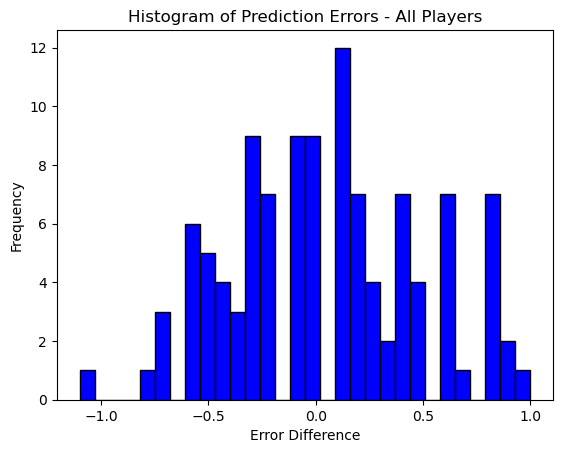

RMSE: 0.447213595499958
MAE: 0.363963963963964


In [92]:
Final_22['Error'] = Final_22['fotmob_rating'] - Final_22['predicted_rating']

plt.hist(Final_22['Error'], bins=30, color='Blue', edgecolor='black')
plt.xlabel('Error Difference')
plt.ylabel('Frequency')
plt.title('Histogram of Prediction Errors - All Players')
plt.show()

print("RMSE:", np.sqrt(np.mean(Final_22['Error']**2)))
print("MAE:", np.mean(np.abs(Final_22['Error'])))

In [90]:
print('Over Predictions')
display(Final_22[['player', 'positions', 'fotmob_rating', 'predicted_rating', 'Error']].sort_values('Error').head(10))
print("")

print('Under Predictions')
display(Final_22[['player', 'positions', 'fotmob_rating', 'predicted_rating', 'Error']].sort_values('Error', ascending = False).head(10))

Over Predictions


,player,positions,fotmob_rating,predicted_rating,Error
41,Achraf Dari,[Right Center Back],5.9,7.0,-1.1
12,Dejan Lovren,[Right Center Back],6.3,7.1,-0.8
43,Noussair Mazraoui,"[Left Wing Back, Left Back]",6.1,6.8,-0.7
15,Josip Juranović,[Right Back],6.5,7.2,-0.7
48,Achraf Hakimi Mouh,"[Right Wing Back, Right Back]",6.4,7.1,-0.7
54,Yahia Attiyat allah,[Left Back],5.8,6.4,-0.6
76,Abdelhamid Sabiri,[Left Center Midfield],5.8,6.4,-0.6
21,Mislav Oršić,[Left Wing],6.0,6.6,-0.6
36,Azzedine Ounahi,"[Left Defensive Midfield, Left Center Midfield...",6.9,7.5,-0.6
59,Jawad El Yamiq,[Right Center Back],6.4,7.0,-0.6



Under Predictions


,player,positions,fotmob_rating,predicted_rating,Error
51,Ousmane Dembélé,[Right Wing],7.4,6.4,1.0
39,Aurélien Djani Tchouaméni,"[Right Defensive Midfield, Center Defensive Mi...",8.2,7.3,0.9
8,Nahuel Molina Lucero,"[Right Back, Right Wing Back]",7.1,6.2,0.9
98,Enzo Fernandez,"[Center Defensive Midfield, Right Center Midfi...",8.3,7.5,0.8
35,Olivier Giroud,[Center Forward],7.2,6.4,0.8
37,Antoine Griezmann,"[Center Attacking Midfield, Right Center Midfi...",8.0,7.2,0.8
42,Jules Koundé,[Right Back],7.6,6.8,0.8
50,Ibrahima Konaté,[Left Center Back],7.5,6.7,0.8
68,Luka Modrić,[Right Defensive Midfield],7.6,6.8,0.8
101,Adrien Rabiot,[Left Defensive Midfield],7.5,6.7,0.8


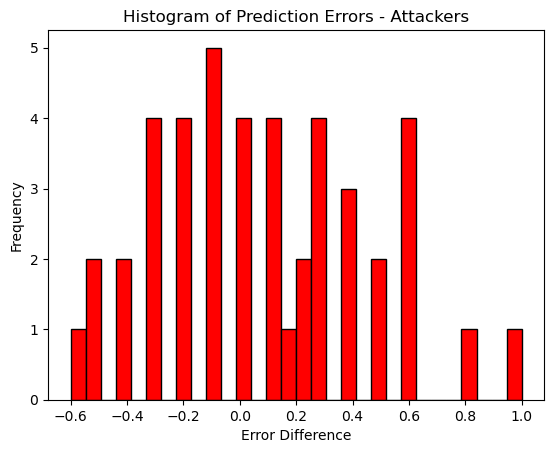

RMSE: 0.3792936017963346
MAE: 0.3068181818181819


In [94]:
# For Attackers
AttackerEval = Final_22[Final_22.is_attacker == 1]

plt.hist(AttackerEval['Error'], bins=30, color='Red', edgecolor='black')
plt.xlabel('Error Difference')
plt.ylabel('Frequency')
plt.title('Histogram of Prediction Errors - Attackers')
plt.show()

print("RMSE:", np.sqrt(np.mean(AttackerEval['Error']**2)))
print("MAE:", np.mean(np.abs(AttackerEval['Error'])))

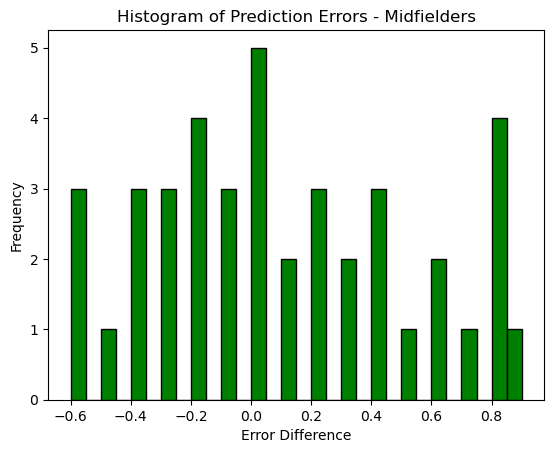

RMSE: 0.438956634337913
MAE: 0.3560975609756097


In [96]:
# For Midfielders
MidfielderEval = Final_22[Final_22.is_midfielder == 1]

plt.hist(MidfielderEval['Error'], bins=30, color='Green', edgecolor='black')
plt.xlabel('Error Difference')
plt.ylabel('Frequency')
plt.title('Histogram of Prediction Errors - Midfielders')
plt.show()

print("RMSE:", np.sqrt(np.mean(MidfielderEval['Error']**2)))
print("MAE:", np.mean(np.abs(MidfielderEval['Error'])))

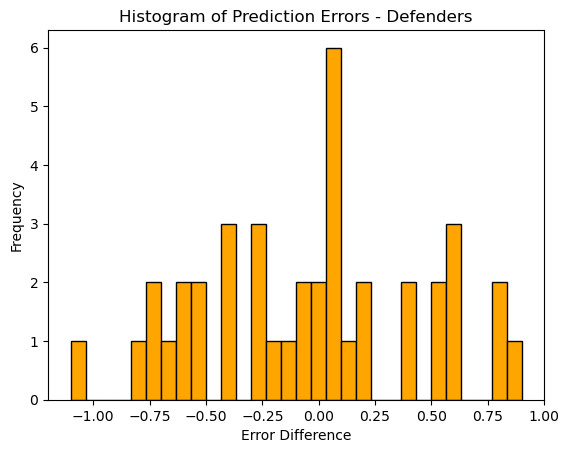

RMSE: 0.48733971724044817
MAE: 0.4


In [97]:
# For Defenders
DefenderEval = Final_22[Final_22.is_defender == 1]

plt.hist(DefenderEval['Error'], bins=30, color='Orange', edgecolor='black')
plt.xlabel('Error Difference')
plt.ylabel('Frequency')
plt.title('Histogram of Prediction Errors - Defenders')
plt.show()

print("RMSE:", np.sqrt(np.mean(DefenderEval['Error']**2)))
print("MAE:", np.mean(np.abs(DefenderEval['Error'])))

### **Summary**
Through the evaluation of each position specific model, we see that all three performed similarly in predicting FotMob’s player ratings. The MAE values ranged between 0.3 and 0.4 while MSE values ranged between 0.3 and 0.47, indicating average errors of roughly 0.3 to 0.4 rating points. Among the three models, the attacker model produced the lowest average error, while the defender model showed the highest error with an MAE of 0.4 and an MSE of 0.49.

While the chosen variables for the model reflect much of the stats used on FotMob's player performance ratings, it is likely that some of the variables may weighted differently to represent important controbutions for eahc of the three group's main responsibility. It is also likely that FotMob may use variables not disclosed in their website.

## **Tableau Information Scrape**

In [75]:
# Used to get Player Team
PlayerInfo = []
for i in AppIds:
    CurrentEvents = sb.events(match_id = i)
    print(i)
    CurrentPlayers = pd.Series(CurrentEvents.player.unique()).dropna().tolist()

    for k in CurrentPlayers:
        PlayerEvents = CurrentEvents[CurrentEvents.player == k]

        if "Goalkeeper" not in PlayerEvents.position.unique():
                playerName = PlayerEvents.player.tolist()[0]
                matchNum = i
                playerTeam = PlayerEvents.team.tolist()[0]

                player_df = pd.DataFrame({"player": [playerName], "matchNum": [matchNum], "Team": [playerTeam]})
                PlayerInfo.append(player_df)

Player_Teams = pd.concat(PlayerInfo, axis=0, ignore_index=True)

# Player_Teams.to_csv("WC22_PlayerTeams.csv")

3869519
3869552
3869684
3869685
